# Prediksi Harga Bitcoin (BTC/IDR) - Model Hybrid CNN-LSTM-Attention (Refined)

Notebook ini berisi implementasi model *Deep Learning* tingkat lanjut untuk memprediksi harga Bitcoin (BTC) terhadap Rupiah (IDR). 

### Pembaruan di Versi Ini:
1. **Custom Loss (Huber Loss)**: Lebih tahan terhadap lonjakan harga ekstrem (outliers) dibanding MSE standar.
2. **Readable Metrics**: Training progress ditampilkan dalam format desimal biasa (bukan scientific `e-05`) agar lebih mudah dipantau.
3. **Directional Accuracy**: Menambahkan metrik untuk melihat seberapa sering model benar menebak arah harga (Naik/Turun).
4. **Visualisasi Lebih Jelas**: Memperbaiki skala sumbu Y agar harga IDR lebih mudah dibaca.

### Arsitektur:
- **CNN**: Ekstraksi pola spasial/lokal.
- **LSTM**: Memori temporal jangka panjang.
- **Attention**: Fokus pada waktu-waktu yang krusial.

In [17]:
# Instalasi library jika belum ada
!pip install ta

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, LSTM, Dense, Dropout, MultiHeadAttention, LayerNormalization, GlobalAveragePooling1D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from ta.momentum import RSIIndicator, StochasticOscillator
from ta.trend import MACD
from ta.volatility import BollingerBands, AverageTrueRange
from ta.volume import OnBalanceVolumeIndicator
import warnings

warnings.filterwarnings('ignore')
print("TensorFlow Version:", tf.__version__)
print("GPU Tersedia:" if tf.config.list_physical_devices('GPU') else "GPU tidak terdeteksi, menggunakan CPU.")

TensorFlow Version: 2.21.0
GPU Tersedia:


## 1. Memuat Data
Kita memuat data 5 tahun terakhir dari Indodax.

In [19]:
df = pd.read_csv('btc_idr_1h_5years.csv')
if 'timestamp' in df.columns:
    df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
    df.set_index('timestamp', inplace=True)
print(f"Total data: {len(df)}")

Total data: 45800


## 2. Feature Engineering
Menambahkan indikator teknikal sebagai fitur tambahan.

In [20]:
def add_technical_indicators(df):
    # Momentum
    df['rsi'] = RSIIndicator(close=df['close']).rsi()
    stoch = StochasticOscillator(high=df['high'], low=df['low'], close=df['close'])
    df['stoch_k'] = stoch.stoch()
    df['stoch_d'] = stoch.stoch_signal()
    
    # Trend
    macd = MACD(close=df['close'])
    df['macd'] = macd.macd()
    df['macd_signal'] = macd.macd_signal()
    
    # Volatility
    bb = BollingerBands(close=df['close'])
    df['bb_high'] = bb.bollinger_hband()
    df['bb_low'] = bb.bollinger_lband()
    df['atr'] = AverageTrueRange(high=df['high'], low=df['low'], close=df['close']).average_true_range()
    
    # Volume
    df['obv'] = OnBalanceVolumeIndicator(close=df['close'], volume=df['volume']).on_balance_volume()
    return df

df = add_technical_indicators(df)
df.dropna(inplace=True)
print(f"Data siap: {df.shape}")

Data siap: (45723, 14)


## 3. Preprocessing
Scaling dan Windowing (60 jam).

In [21]:
features = ['open', 'high', 'low', 'close', 'volume', 'rsi', 'stoch_k', 'stoch_d', 'macd', 'macd_signal', 'bb_high', 'bb_low', 'atr', 'obv']
target_col = 'close'

scaler_features = MinMaxScaler(feature_range=(0, 1))
scaler_target = MinMaxScaler(feature_range=(0, 1))

scaled_features = scaler_features.fit_transform(df[features].values)
scaled_target = scaler_target.fit_transform(df[[target_col]].values)

def create_sequences(features, target, window_size=60):
    X, y = [], []
    for i in range(len(features) - window_size):
        X.append(features[i : i + window_size])
        y.append(target[i + window_size])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_features, scaled_target, 60)

n_train = int(len(X) * 0.8)
n_val = int(len(X) * 0.1)

X_train, y_train = X[:n_train], y[:n_train]
X_val, y_val = X[n_train : n_train + n_val], y[n_train : n_train + n_val]
X_test, y_test = X[n_train + n_val :], y[n_train + n_val :]

print(f"Training: {X_train.shape}, Test: {X_test.shape}")

Training: (36530, 60, 14), Test: (4567, 60, 14)


## 4. Arsitektur Model (Hybrid CNN-LSTM-Attention)
Kita menggunakan **Huber Loss** agar model tidak terlalu sensitif terhadap 'noise' atau anomali harga yang ekstrem.

In [22]:
def build_model(input_shape):
    inputs = Input(shape=input_shape)
    
    # CNN Part
    x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(inputs)
    x = MaxPooling1D(pool_size=2)(x)
    x = Conv1D(filters=128, kernel_size=3, activation='relu', padding='same')(x)
    
    # LSTM Part
    x = LSTM(128, return_sequences=True)(x)
    x = Dropout(0.2)(x)
    x = LSTM(64, return_sequences=True)(x)
    
    # Attention Part
    # AI akan belajar jam mana yang paling penting dalam 60 jam terakhir
    attention = MultiHeadAttention(num_heads=4, key_dim=64)(x, x)
    x = LayerNormalization()(attention + x)
    
    # Output Part
    x = GlobalAveragePooling1D()(x)
    x = Dense(32, activation='relu')(x)
    outputs = Dense(1)(x)
    
    model = Model(inputs, outputs)
    
    # Custom Compile: Huber Loss
    # Huber loss menggabungkan MSE (untuk error kecil) dan MAE (untuk error besar/outliers)
    model.compile(optimizer='adam', loss=tf.keras.losses.Huber(delta=1.0), metrics=['mae'])
    return model

model = build_model((X_train.shape[1], X_train.shape[2]))
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 60, 14)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 60, 64)    │      2,752 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_2     │ (None, 30, 64)    │          0 │ conv1d_4[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 30, 128)   │     24,704 │ max_pooling1d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_4 (LSTM)       │ (None, 30, 128)   │    131,584 │ conv1d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 30, 128)   │          0 │ lstm_4[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_5 (LSTM)       │ (None, 30, 64)    │     49,408 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 64)    │     66,368 │ lstm_5[0][0],     │
│ (MultiHeadAttentio… │                   │            │ lstm_5[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 30, 64)    │          0 │ multi_head_atten… │
│                     │                   │            │ lstm_5[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 64)    │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 32)        │      2,080 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │         33 │ dense_4[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 277,057 (1.06 MB)

 Trainable params: 277,057 (1.06 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Pelatihan Model (Readable Progress)
Gunakan custom callback agar angka mudah dibaca.

In [23]:
class ReadableProgress(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        loss = logs.get('loss')
        v_loss = logs.get('val_loss')
        mae = logs.get('mae')
        print(f"\rE{epoch+1:02d} | Loss: {loss:.6f} | Val_L: {v_loss:.6f} | MAE: {mae:.6f}", end="")

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6),
    ReadableProgress()
]

print("Training Dimulai...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=64,
    callbacks=callbacks,
    verbose=0
)
print("\nSelesai!")

Training Dimulai...
E50 | Loss: 0.000008 | Val_L: 0.000018 | MAE: 0.002765
Selesai!


## 6. Panduan Tuning (Parameter Naik/Turun)

| Parameter | Jika Hasil Jelek (Undertesting) | Jika Hasil Terlalu Hafal (Overfitting) |
|-----------|---------------------------------|-----------------------------------------|
| `Learning Rate` | **Naikkan** sedikit ke 0.002 | **Turunkan** ke 0.0001 |
| `LSTM Units` | **Naikkan** (misal 128 -> 256) | **Turunkan** (misal 128 -> 64) |
| `Dropout` | **Turunkan** (misal 0.2 -> 0.1) | **Naikkan** (misal 0.2 -> 0.4) |
| `Batch Size` | **Turunkan** (misal 64 -> 32) | **Naikkan** (misal 64 -> 128) |
| `Filters CNN` | **Naikkan** (misal 64 -> 128) | **Turunkan** |
| `delta (Huber)` | **Naikkan** agar lebih sensitif | **Turunkan** agar lebih stabil |

## 7. Evaluasi & Metrik Trading

143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

--- HASIL EVALUASI ---
MAE (Selisih Rata-rata) : Rp 8,945,125
MAPE (Persen Error)     : 1.30%
Directional Accuracy    : 48.75% (Akurasi Arah Naik/Turun)


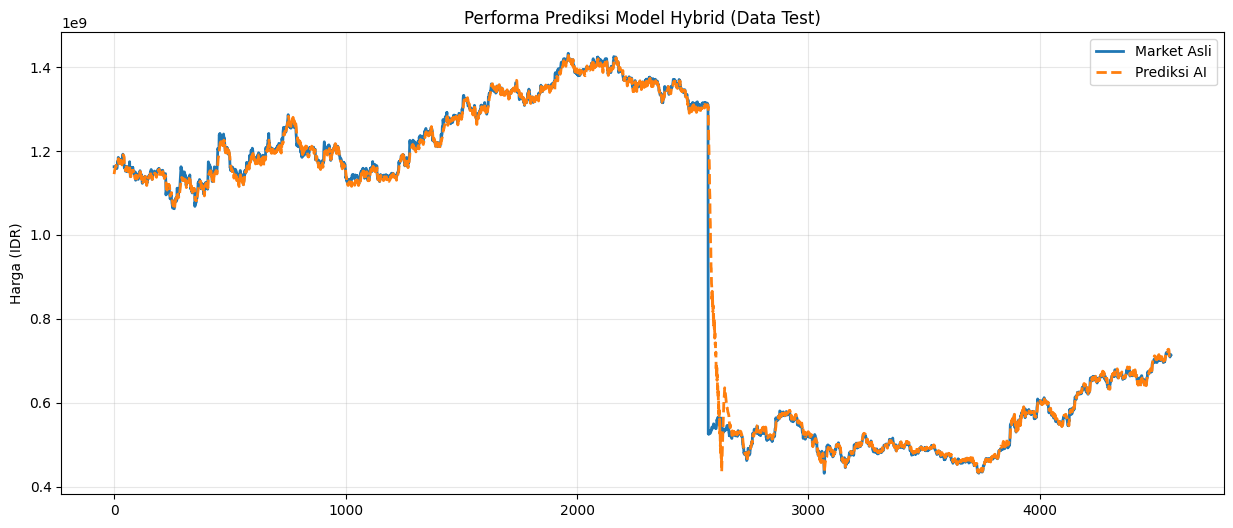

In [24]:
y_pred_scaled = model.predict(X_test)
y_pred = scaler_target.inverse_transform(y_pred_scaled)
y_true = scaler_target.inverse_transform(y_test)

mae = mean_absolute_error(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Metrik Spesifik Trading: Directional Accuracy
# Seberapa sering AI benar menebak harga akan naik atau turun?
def directional_accuracy(y_true, y_pred):
    true_diff = np.diff(y_true.flatten())
    pred_diff = np.diff(y_pred.flatten())
    correct_direction = np.sign(true_diff) == np.sign(pred_diff)
    return np.mean(correct_direction) * 100

da = directional_accuracy(y_true, y_pred)

print(f"\n--- HASIL EVALUASI ---")
print(f"MAE (Selisih Rata-rata) : Rp {mae:,.0f}")
print(f"MAPE (Persen Error)     : {mape:.2f}%")
print(f"Directional Accuracy    : {da:.2f}% (Akurasi Arah Naik/Turun)")

# Visualisasi
plt.figure(figsize=(15, 6))
plt.plot(y_true, label='Market Asli', color='#1f77b4', linewidth=2)
plt.plot(y_pred, label='Prediksi AI', color='#ff7f0e', linestyle='--', linewidth=2)
plt.title('Performa Prediksi Model Hybrid (Data Test)')
plt.ylabel('Harga (IDR)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 8. Analisis Hasil
Jika garis prediksi (orange) terlihat selalu terlambat mengikuti garis asli (biru), itu tandanya model sedang mengalami 'lagging' (hanya menebak harga sebelumnya). 

**Cara Memperbaiki Lag:**
- Tambahkan fitur volume yang lebih kompleks.
- Gunakan **Differential Prediction** (menebak selisih harga, bukan harga mentah).
- Perkecil `WINDOW_SIZE` jika pasar sangat volatil.

## 9. Menyimpan Model & Scaler
Agar model ini bisa digunakan di aplikasi lain (seperti Webhook atau Bot Live), kita harus menyimpan file model (`.keras`) dan file scaler (`.pkl`).

In [25]:
import joblib
import os

# 1. Simpan Model
model_path = 'btc_idr_hybrid_v2.keras'
model.save(model_path)

# 2. Simpan Scaler (Penting! Tanpa ini, AI tidak bisa memproses data live dengan benar)
joblib.dump(scaler_features, 'scaler_features_v2.pkl')
joblib.dump(scaler_target, 'scaler_target_v2.pkl')

print(f"✅ Model disimpan di: {model_path}")
print(f"✅ Scaler disimpan di: scaler_features_v2.pkl & scaler_target_v2.pkl")
print(f"\nUkuran Model: {os.path.getsize(model_path) / 1024:.2f} KB")

✅ Model disimpan di: btc_idr_hybrid_v2.keras
✅ Scaler disimpan di: scaler_features_v2.pkl & scaler_target_v2.pkl

Ukuran Model: 3332.64 KB


## 10. Contoh Cara Load & Prediksi Data Baru
Gunakan kode di bawah ini di script Python (Webhook) Anda nanti.

In [26]:
'''
import tensorflow as tf
import joblib
import numpy as np

# Load segalanya
loaded_model = tf.keras.models.load_model('btc_idr_hybrid_v2.keras')
loaded_scaler_feat = joblib.load('scaler_features_v2.pkl')
loaded_scaler_target = joblib.load('scaler_target_v2.pkl')

# Asumsikan 'new_data_60h' adalah array (60, 14) yang sudah di-preprocess
# pred_scaled = loaded_model.predict(new_data_60h.reshape(1, 60, 14))
# pred_real = loaded_scaler_target.inverse_transform(pred_scaled)
'''

"\nimport tensorflow as tf\nimport joblib\nimport numpy as np\n\n# Load segalanya\nloaded_model = tf.keras.models.load_model('btc_idr_hybrid_v2.keras')\nloaded_scaler_feat = joblib.load('scaler_features_v2.pkl')\nloaded_scaler_target = joblib.load('scaler_target_v2.pkl')\n\n# Asumsikan 'new_data_60h' adalah array (60, 14) yang sudah di-preprocess\n# pred_scaled = loaded_model.predict(new_data_60h.reshape(1, 60, 14))\n# pred_real = loaded_scaler_target.inverse_transform(pred_scaled)\n"